## Custom Drift Compensation Drift



In [3]:
import math
import random
import numpy as np
import scipy.io

# set the seed for reproducibility
np.random.seed(9)

def compute_MAE(x:np.array, y:np.array, verbose: bool = False )->float:
    """
    A function to compute the mean absolute error between two arrays

    Args:
        x (np.array): the first array
        y (np.array): the second array
        verbose (bool): a flag to print some information about the error

    Returns:
        float: the mean absolute error
    """

    diff = abs(x - y)
    indexes = np.argsort(diff)
    if verbose:
        print("Indexes of the most significant terms: ", indexes[-10:][::-1])
        print("Values of the most significant terms: ", diff[indexes[-10:][::-1]])
    # compute the error using the ideal currents and MAE
    mae = np.mean(diff)
    if verbose:
        print("MAE: ", mae)
    
    return mae

def compute_MSE(x:np.array, y:np.array, verbose: bool = False )->float:
    """
    A function to compute the mean square error between two arrays

    Args:
        x (np.array): the first array
        y (np.array): the second array
        verbose (bool): a flag to print some information about the error

    Returns:
        float: the mean square erro
    """

    diff = abs(x - y)
    indexes = np.argsort(diff)
    if verbose:
        print("Indexes of the most significant terms: ", indexes[-10:][::-1])
        print("Values of the most significant terms: ", diff[indexes[-10:][::-1]])
    # compute the error using the ideal currents and MSE
    mse = np.mean(diff**2)
    if verbose:
        print("MSE: ", mse)
    
    return mse

def compute_norm(x:np.array, y:np.array, verbose: bool = False )->float:
    """
    A function to compute the norm between two arrays

    Args:
        x (np.array): the first array
        y (np.array): the second array
        verbose (bool): a flag to print some information about the error

    Returns:
        float: the norm
    """

    diff = abs(x - y)
    indexes = np.argsort(diff)
    if verbose:
        print("Indexes of the most significant terms: ", indexes[-10:][::-1])
        print("Values of the most significant terms: ", diff[indexes[-10:][::-1]])
    # compute the error using the ideal currents and MSE
    norm = np.linalg.norm(diff)
    if verbose:
        print("Norm: ", norm)
    
    return norm

def compute_SUM_DIFF_SQR(x:np.array, y:np.array, verbose: bool = True )->float:
    """
    A function to compute difference between the sums of two arrays
    """    
    # check that all the values of x and y are positive
    if np.any(x<0) or np.any(y<0):
        # Print the values of the arrays that are negative
        if np.any(x<0):
            print("Values of x that are negative: ", x[x<0])
        if np.any(y<0):
            print("Values of y that are negative: ", y[y<0])
        raise ValueError("All the values of the arrays should be positive")

    d = (np.sum(x)-np.sum(y))**2
    if verbose:
        print("Difference between the sums: ", d)
    return d

""" Helper functions to conpute the drift exponent nu"""
def mu_nu(g_t:float)->float:
    g_t = max(g_t, 0.1e-9)
    return min(max(-0.0155*np.log(g_t)+0.0244, 0.049),0.1)

def sigma_nu(g_t:float)->float:
    g_t = max(g_t, 0.1e-9)
    return min(max(-0.0125*np.log(g_t)-0.0059, 0.008),0.045)



def g_drift_IBM(g_t:float, t_c:float, t:float)->float:
    """
    A function to model the drift of the conductance value. For simplicity, suppose the g_prog = g_t passed as argument

    Args:
        g_t (float): the target conductance value
        t_c (float): the time at which we know the conductance value g_prog
        t (float): the time at which we want to know the conductance value

    Returns:
        float: the conductance value at time t
    
    """
    mu = mu_nu(g_t)
    sigma = sigma_nu(g_t)
    nu = np.random.normal(mu, sigma)
    return g_t*(t/t_c)**(-nu)


def g_drift_median_IBM(g_t:float, t_c:float, t:float)->float:
    """
    A function to model only the drift of the conductances only considering the median value of the drift exponent nu

    Args:
        g_t (float): the target conductance value
        t_c (float): the time at which we know the conductance value g_prog
        t (float): the time at which we want to know the conductance value

    Returns:
        float: the conductance value at time t
    
    """
    mu = mu_nu(g_t)
    return g_t*(t/t_c)**(-mu)


class CustomDrifter:

    def __init__(self, file_name:str):
        """ A class to import the median and std deviation values for the drift of the conductance value out"""
        mat = scipy.io.loadmat(file_name)
        self.types = mat['str'][0]
        self.types = [str(self.types[i][0]) for i in range(len(self.types))]
        self.mu = mat['ww_mdn'] # a list of median values for the different values of target conductances (differential), based on the type of noise
        self.sigma = mat['ww_std'] # a list of std deviation values for the different values of target conductances (differental), based on the type of noise
        self.mu_g = mat['gg_mdn'] # a list of median values for the different values of target conductances (single), based on the type of noise
        self.sigma_g = mat['gg_std'] # a list of std deviation values for the different values of target conductances (single), based on the type of noise

    def expose_types(self):
        return self.types
    
    def g_drift_custom(self, g_t:float, typ: str, levels: int, g_max: float, median:bool = True, std: bool = True)->float:
        """
        A function to model the drift of the conductance value based on the type of noise. The conductances considered 
        are the single values (non-compensated)

        Args:
            g_t (float): the target conductance value (g_t in the range [0 uS, 80 uS])
            typ (str): the type of noise to be considered

        Returns:
            float: the conductance value 'at time t'
        """
        if levels > 9 or levels < 1 or levels%1 != 0:
            raise ValueError("The number of levels should be between 1 and 9 and should be odd")
        
        # access the median and std deviation values based on the type of noise
        mu = [self.mu_g[i][self.types.index(typ)] for i in range(self.mu_g.shape[0])]
        # print(mu)
        sigma = [self.sigma_g[i][self.types.index(typ)] for i in range(self.sigma_g.shape[0])]
        # append 0 to mu and sigma
        #print(mu)
        mu = [0.] + mu
        sigma = [0.] + sigma
        mu = mu[0:len(mu)//2+1]
        sigma = sigma[0:len(sigma)//2+1]
        # interpolate the values at the number of levels selected
        g_range = np.linspace(0, g_max, levels)
        mu = np.interp(g_range, np.linspace(0, g_max, len(mu)), mu)
        sigma = np.interp(g_range, np.linspace(0, g_max, len(sigma)), sigma)
        level = round((g_t/g_max)*(levels-1))
        

        mu = mu[level]
        sigma = sigma[level]
        if median and std:
            g_drifted = float((mu + np.random.normal(0, sigma)))
            if g_drifted < 0:
                g_drifted = 0.
            return g_drifted
        elif median:
            g_drifted = float(mu)
            return g_drifted
        elif std:
            # g_drifted = float(np.random.normal(0, sigma) if np.random.normal(0, sigma) > 0. else 0.)
            g_drifted = float(sigma)
            return g_drifted
        else:
            raise ValueError("You should choose at least one of the median or std deviation values")


    def w_drift_custom(self, w_t:float, typ: str, levels: int, g_max: float, median : bool = True, std: bool = True)->float:
        """
        A function to model the drift of the conductance value based on the type of noise. The drifted conductance values considered
        are the differential values (already compensated)

        Args:
            w_t (float): the target conductance value (w_t in the range [-40 uS, 40 uS])
            typ (str): the type of noise to be considered

        Returns:
            float: the conductance value 'at time t'
        
        """
        if(levels > 9 or levels < 1 or levels%1 != 0):
            raise ValueError("The number of levels should be between 1 and 9 and should be odd")

        # access the median and std deviation values based on the type of noise
        mu = [self.mu[i][self.types.index(typ)] for i in range(self.mu.shape[0])]
        sigma = [self.sigma[i][self.types.index(typ)] for i in range(self.sigma.shape[0])]
        # get rid of the negative values
        # interpolate the values at the number of levels
        mu = [0.] + mu[len(mu)//2+1:]
        # print(mu)
        sigma = [0.] +sigma[len(sigma)//2+1:]
        # print(sigma)
        g_range = np.linspace(0, g_max, levels)
        mu = np.interp(g_range, np.linspace(0, g_max, len(mu)), mu)
        sigma = np.interp(g_range, np.linspace(0, g_max, len(sigma)), sigma)
        # determine to which level the target conductance belongs to
        level = round((w_t/g_max)*(levels-1))
        # get the median and std deviation values for the target conductance
        mu = mu[level]
        sigma = sigma[level]
        if median and std:
            g_drifted = float((mu + np.random.normal(0, sigma)))
            if g_drifted < 0:
                g_drifted = 0.
            return g_drifted
        elif median:
            g_drifted = float(mu)
            return g_drifted
        elif std:
            # g_drifted = float(np.random.normal(0, sigma) if np.random.normal(0, sigma) > 0. else 0.)
            g_drifted = float(sigma)
            return g_drifted
        else:
            raise ValueError("You should choose at least one of the median or std deviation values")
        
    
    # hook to drift the conductance value
    def __call__(self, g_t:float, typ: str, levels: int, g_max: float):
        #return self.w_drift_custom(g_t, typ, levels, g_max) 
        return self.g_drift_custom(g_t, typ, levels, g_max)


def DAC_quantizer(input:np.array, bits:int, Vdd: float, amax: float)->np.array:
    """
    A function to model the quantization operation user in the DAC

    Args:
        input (np.array): the input values to be quantizedm(int32)
        bits (int): the number of bits for the quantization
        Vdd (float): the supply voltage used
        amax (float): the maximum value of the input
    
    Returns:
        output (np.array): the quantized values

    """
    # rescale the input values
    input = input/amax*Vdd
    # define the quantization levels
    levels = 2**bits
    # define the step size
    delta = Vdd/levels
    # quantize the input values
    output = np.round(input/delta)*delta
    return output
    
    




In [4]:


CustomDrifter('../data/matlab/4bit.mat').w_drift_custom(0e-6, 'Prog', 9, 40e-6, median=True, std=False)

0.0

## Statistic analysis


In [5]:
import math
import random
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# chose different sizes for the tile
N_values = [128] #, 128, 256, 256, 512, 512]
M_values = [64]# ,128, 128, 256, 256, 512]
t_values = [1e-3,0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200,5000]
t_c = 1e-3
t = t_values[-3]
V_dd = 0.3
max_g = 40e-6

max_input =10
n_levels = 5


BITS = 0
DISTRIBUTIONS = ["NORMAL", "UNIFORM"]
CHOSEN_DISTRIBUTION = "NORMAL"
DRIFT_MODELS = ["IBM", "EXPERIMENTAL"]
CHOSEN_DRIFT_MODEL = "EXPERIMENTAL"
drifter = CustomDrifter('../data/matlab/4bit.mat')
types = drifter.expose_types()
CHOSEN_TYPE = types[4]
print("Chosen type: ", CHOSEN_TYPE)

import os
# create a drift dicectory if it does not exist
if not os.path.exists(f"./d={CHOSEN_TYPE}"):
    os.makedirs(f"./d={CHOSEN_TYPE}")
# within the exact drift directory, create the level directory
if not os.path.exists(f"./d={CHOSEN_TYPE}/lv={n_levels}"):
    os.makedirs(f"./d={CHOSEN_TYPE}/lv={n_levels}")

# for each couple of N,M values, generate a simulation crossbar
crossbars = []
for N,M in zip(N_values, M_values):
    crossbar = np.zeros((N,M))
    for i in range(N):
        crossbar[i] = np.clip(abs(np.random.normal(0, max_g/3, M)),0,max_g) if  CHOSEN_DISTRIBUTION == "NORMAL" else abs(np.random.uniform(0, max_g, M))
        # quantize the conductances
        crossbar[i] = np.round(crossbar[i]/max_g*(n_levels-1)) * max_g/(n_levels-1)
    crossbars.append(crossbar)

CONDUCTANCE_VALUES = np.unique(np.array(crossbars[0]).flatten())
print("Conductanqe values: ", CONDUCTANCE_VALUES)
print("W_drifted_mean: ", [drifter.w_drift_custom(g, CHOSEN_TYPE, n_levels, max_g, median=True, std=False) for g in CONDUCTANCE_VALUES])
print("W_drifted_std: ", [drifter.w_drift_custom(g, CHOSEN_TYPE, n_levels, max_g, median=False, std=True) for g in CONDUCTANCE_VALUES])
print("G_drifted_mean: ", [drifter.g_drift_custom(g, CHOSEN_TYPE, n_levels, max_g, median=True, std=False) for g in CONDUCTANCE_VALUES])
print("G_drifted_std: ", [drifter.g_drift_custom(g, CHOSEN_TYPE, n_levels, max_g, median=False, std=True) for g in CONDUCTANCE_VALUES])

# determine the number of samples to be used for estimations
n_samples = [10*N_values[i] for i in range(len(M_values))]
inputs = []
for i in range(len(M_values)):
    inputs.append(np.zeros((n_samples[i], N_values[i])))
    for j in range(n_samples[i]):
        inputs[-1][j,:] = np.clip(abs(np.random.normal(0, max_input/3, N_values[i])),0, max_input) if CHOSEN_DISTRIBUTION == "NORMAL" else np.random.uniform(0, max_input, N_values[i])



Chosen type:  1d,90°C
Conductanqe values:  [0.e+00 1.e-05 2.e-05 3.e-05 4.e-05]
W_drifted_mean:  [0.0, 9.543592508679061e-06, 1.8866118496415166e-05, 2.8612965564762493e-05, 3.6067454424839574e-05]
W_drifted_std:  [0.0, 5.099370333723801e-06, 4.832355470839534e-06, 4.2315294337048386e-06, 4.525172042590256e-06]
G_drifted_mean:  [0.0, 3.3348359960349972e-06, 6.965760717398111e-06, 1.2880931209776344e-05, 1.9979072835540923e-05]
G_drifted_std:  [0.0, 9.438733484578853e-07, 1.5819260219459585e-06, 2.264454785196951e-06, 2.8778577303854015e-06]


In [6]:
   
# compute the reference currents
reference_currents = []
for i in range(len(M_values)):
    V_ref = np.array([V_dd]*N_values[i])
    reference_currents.append(np.zeros(M_values[i]))
    for j in range(M_values[i]):
        reference_currents[i][j] = np.dot(crossbars[i][:,j], V_ref)

In [7]:
from copy import deepcopy
# save, for each conductance level, the ideal, single and differential drifted conductances in a pandas dataframe

ideal_conductances = { g: [] for g in CONDUCTANCE_VALUES}
single_conductances = { g: [] for g in CONDUCTANCE_VALUES}
differential_conductances = { g: [] for g in CONDUCTANCE_VALUES}

#drift the conductances on the tiles, based on the model chosen
single_crossbars = [np.zeros((N_values[i], M_values[i])) for i in range(len(M_values))]
differential_crossbars = [np.zeros((N_values[i], M_values[i])) for i in range(len(M_values))]
for i in range(len(M_values)):
    for j in range(N_values[i]):
        for k in range(M_values[i]):

            single_crossbars[i][j,k] = drifter.g_drift_custom(crossbars[i][j,k], CHOSEN_TYPE, n_levels, max_g, median=True, std=True)
            differential_crossbars[i][j,k] = drifter.w_drift_custom(crossbars[i][j,k],  CHOSEN_TYPE, n_levels, max_g, median=True, std=True)
            
            if i == 0:
                # append the values to the dictionaries
                ideal_conductances[crossbars[i][j,k]].append(crossbars[i][j,k]* 1e6)
                single_conductances[crossbars[i][j,k]].append(single_crossbars[i][j,k]* 1e6)
                differential_conductances[crossbars[i][j,k]].append(differential_crossbars[i][j,k] * 1e6)

    
            if single_crossbars[i][j,k] < 0.:
                ValueError("The conductance value should be positive")
            if differential_crossbars[i][j,k] < 0.:
                ValueError("The conductance value should be positive")
    


In [8]:


# and the drifted reference currents
single_reference_currents = []
for i in range(len(M_values)):
    V_ref = np.array([V_dd]*N_values[i])
    single_reference_currents.append(np.zeros(M_values[i]))
    for j in range(M_values[i]):
        single_reference_currents[i][j] = np.dot(single_crossbars[i][:,j], V_ref)

differential_reference_currents = []
for i in range(len(M_values)):
    V_ref = np.array([V_dd]*N_values[i])
    differential_reference_currents.append(np.zeros(M_values[i]))
    for j in range(M_values[i]):
        differential_reference_currents[i][j] = np.dot(differential_crossbars[i][:,j], V_ref)


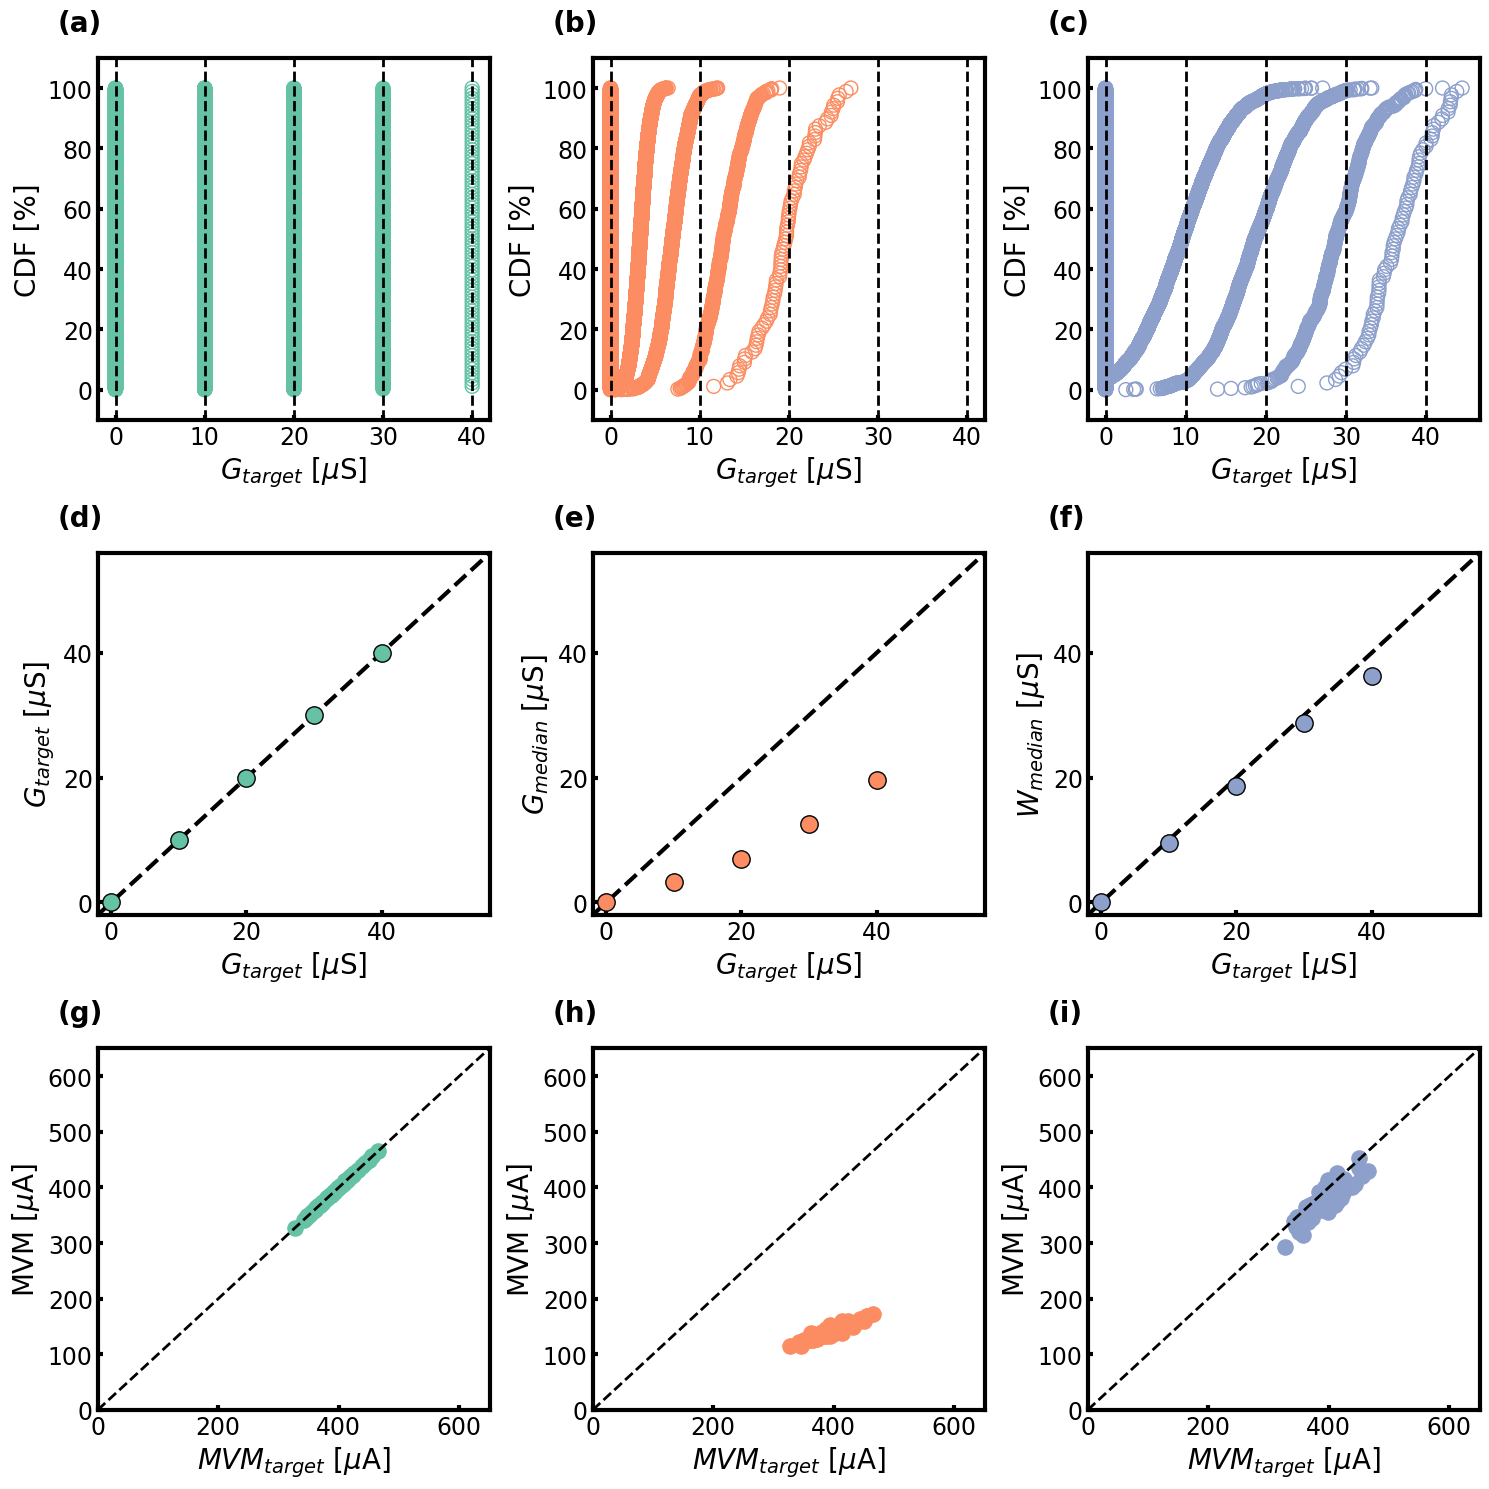

In [14]:
# For tile 0 (ideal, drifted single, drifted differential), plot median and std deviation values for each key in the dictionary
# of conductances
fig, ax = plt.subplot_mosaic([["(a)", "(b)", "(c)"], ["(d)", "(e)", "(f)"], ["(g)", "(h)", "(i)"]], figsize=(15,15))
cmap = plt.get_cmap("Set2")
colors = [cmap(i) for i in range(3)]

def plot_conductance_values(ax, conductances:dict, currents: list, ideal_currents: list, title:str, color:str):


    fontsize = 20
    labelsize = 17
    median = np.zeros(len(CONDUCTANCE_VALUES))
    std = np.zeros(len(CONDUCTANCE_VALUES))
    currents = np.array(currents) * 1e6
    ideal_currents= np.array(ideal_currents) * 1e6
    kwargs = dict( marker='o', facecolors="none", edgecolors=color, s=100)
    for k, key in enumerate(CONDUCTANCE_VALUES):
        conductances[key] = np.array(conductances[key])
        
        # CDFs of the conductances: for each target condunctance values, we plot the 
        sorted_vals = np.sort(conductances[key])
        cdf = np.arange(1,len(sorted_vals)+1)/len(sorted_vals)*100
        # trace vertical lines to better visualize the CDF
        ax[0].axline((key*1e6, 0), (key*1e6, 1), color="k", lw=2, linestyle='--')
        ax[0].scatter(sorted_vals, cdf, color=color, **kwargs)
        

        median[k] = np.median(conductances[key])
        std[k] = np.std(conductances[key])
    error_kwargs = dict(lw=2, capsize=5, capthick=2, ecolor='black', mec='black')
    ax[1].errorbar(np.array(CONDUCTANCE_VALUES) * 1e6, median, fmt='o', color=color, markersize=12.5, **error_kwargs)

    # plot the currents
    ax[2].scatter(ideal_currents, currents, color=color, s=120)


    # layout
    # for each plot, make the frame thicker and the ticks inwards and thicker
    for i in range(3):
        ax[i].spines['top'].set_linewidth(3)
        ax[i].spines['right'].set_linewidth(3)
        ax[i].spines['left'].set_linewidth(3)
        ax[i].spines['bottom'].set_linewidth(3)
        ax[i].tick_params(axis='both', direction='in', width=3)
    # set limits for the x- and y-axes
    border = 0.4
    ax[0].set_ylim(-10, 110)
    ax[0].set_yticks(np.arange(0, 110, 20))
    ax[1].set_xlim(0-2, max_g * 1e6 + border * max_g * 1e6)
    ax[1].set_ylim(0-2, max_g * 1e6 + border * max_g * 1e6)
    ax[1].set_yticks(np.arange(0, max_g * 1e6 + border * max_g * 1e6, 20))
    # plot the bisector to end past the limits of the plot
    ax[1].axline((0,0), slope=1, color='black', lw=3, linestyle='--')
    # for the currents, format the ticks labels to be in scientific notation
    #ax[2].ticklabel_format(axis='both', style='sci', scilimits=(0,0))
    ax[2].set_xlim(0, max(ideal_currents) + border * max(ideal_currents))
    ax[2].set_ylim(0, max(ideal_currents) + border * max(ideal_currents))
    # and add a bisector
    ax[2].axline((min(ideal_currents), min(ideal_currents)), (max(ideal_currents), max(ideal_currents)), color='black', lw=2, linestyle='--')
    ax[0].set_xlabel(r"$G_{target}$ [$ \mu $S]")
    ax[0].set_ylabel("CDF [%]")
    ax[1].set_xlabel(r"$G_{target}$ [$ \mu $S]")
    ax[1].set_ylabel(r"$G_{median}$ [$\mu$S]") if title == "single drifted" else ax[1].set_ylabel(r"$W_{median}$ [$\mu$S]") if title == "differential drifted" else ax[1].set_ylabel(r"$G_{target}$ [$\mu$S]")
    ax[2].set_xlabel(r"$MVM_{target}$ [$\mu$A]")
    ax[2].set_ylabel(r"MVM [$\mu$A]")
    # make both the lables and the tick labels bigger
    for i in range(3):
        ax[i].set_xlabel(ax[i].get_xlabel(), fontsize=fontsize)
        ax[i].set_ylabel(ax[i].get_ylabel(), fontsize=fontsize)
        ax[i].tick_params(axis='both', which='major', labelsize=labelsize)

    # set a title for the columns of plots, a bit spaced from the plot
    #ax[0].set_title(title, fontsize=20, fontweight='bold', y=1.05)
    #ax[1].set_title(title, fontsize=20, fontweight='bold', y=1.05)
    #ax[2].set_title(title, fontsize=20, fontweight='bold', y=1.05)

    

    


plot_conductance_values([ax["(a)"], ax["(d)"], ax["(g)"]], ideal_conductances, reference_currents[0], reference_currents[0], "ideal", colors[0])
plot_conductance_values([ax["(b)"], ax["(e)"], ax["(h)"]], single_conductances, single_reference_currents[0], reference_currents[0], "single drifted", colors[1])
plot_conductance_values([ax["(c)"], ax["(f)"], ax["(i)"]], differential_conductances, differential_reference_currents[0], reference_currents[0], "differential drifted", colors[2])


# add the labels for the plots
from matplotlib.transforms import ScaledTranslation
for label, a in ax.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    a.text(
        0.0, 1.0, label, transform=(
            a.transAxes + ScaledTranslation(-20/50, +15/72, fig.dpi_scale_trans)),
        fontsize=20, va='bottom', fontweight='bold')


plt.tight_layout()




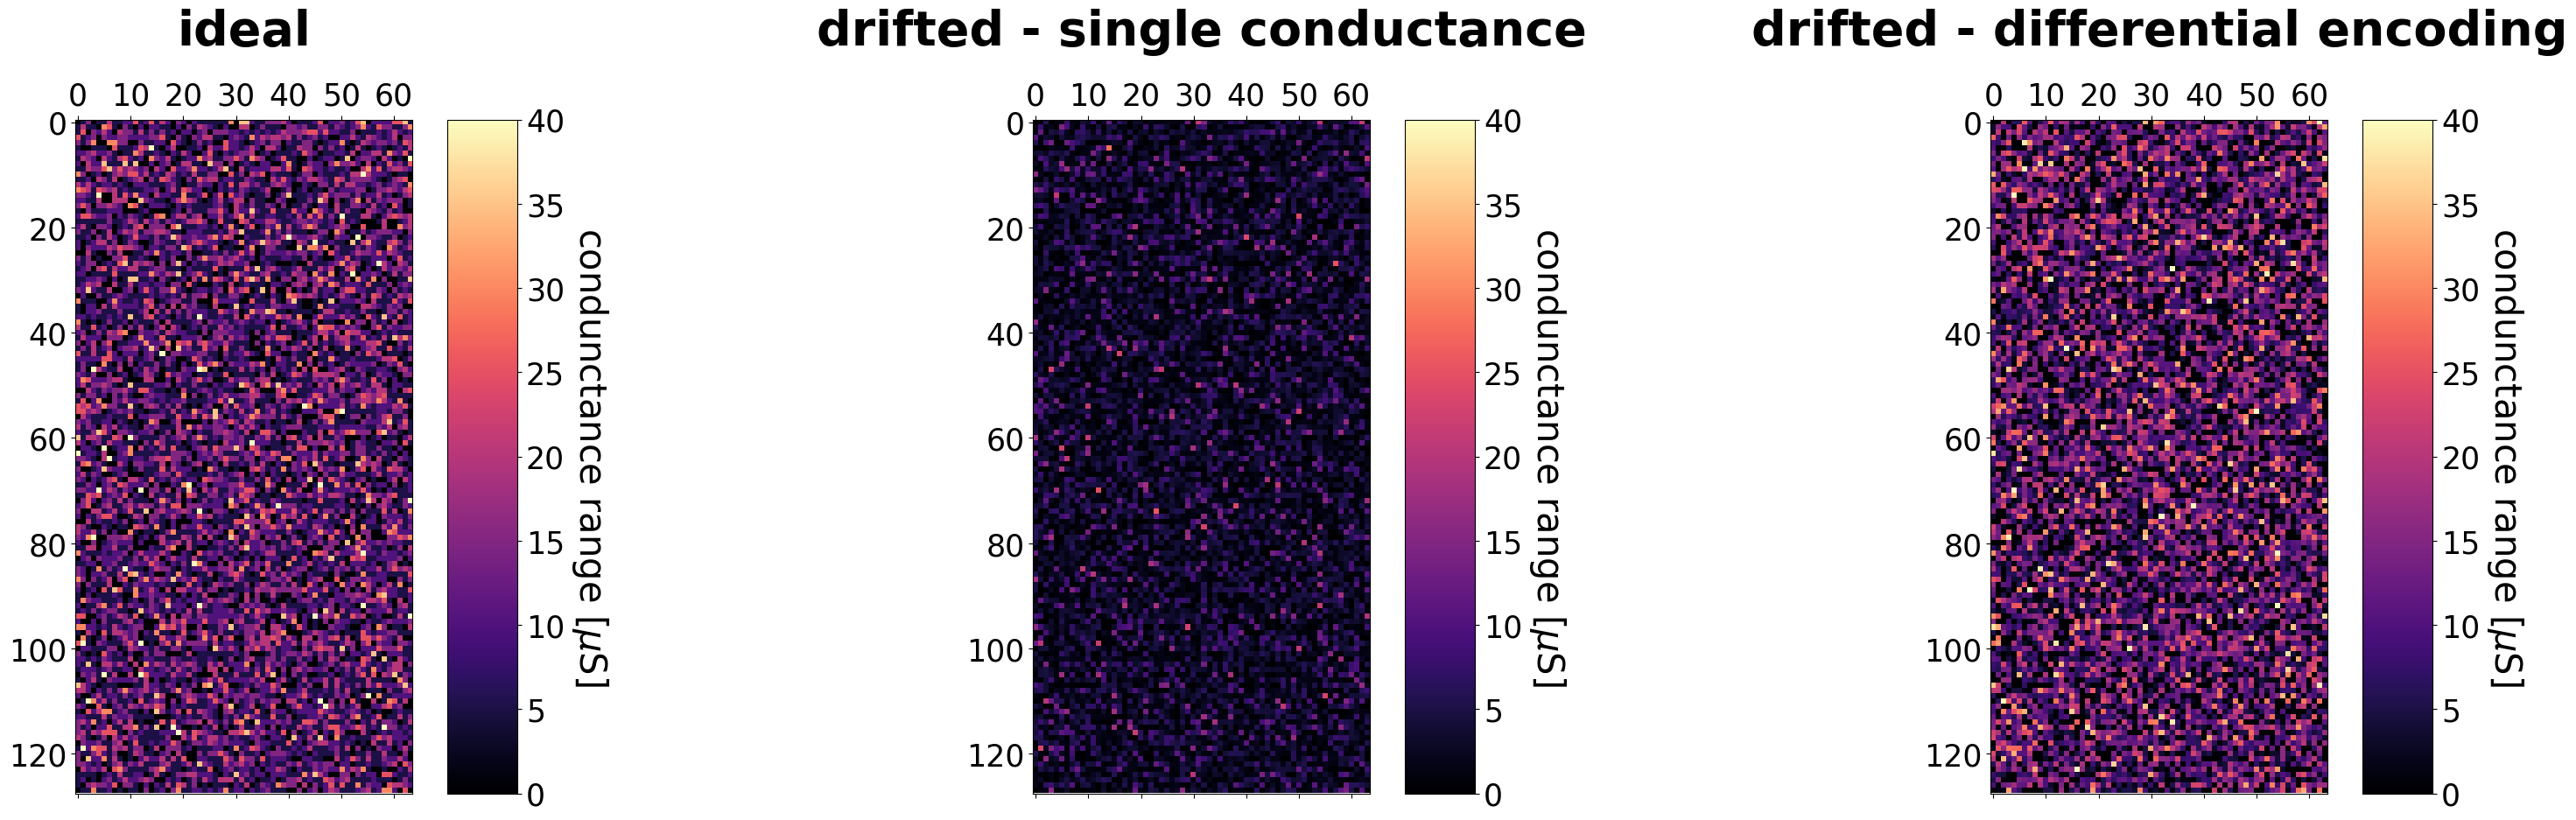

In [8]:
# PLOT THE FIRST CROSSBAR, manually setting the min and max values for the colorbar
fig, ax = plt.subplots(1,3, figsize=(40,10))
im1 = ax[0].matshow(crossbars[0] * 1e6, cmap="magma",origin='upper', vmin=0, vmax=1*max_g*1e6)
im_ratio = crossbars[0].shape[0]/crossbars[0].shape[1]
cax = fig.add_axes([ax[0].get_position().x1+0.01,ax[0].get_position().y0,0.02,ax[0].get_position().height])
cbar = plt.colorbar(im1, cax=cax)
cbar.ax.set_ylabel(r"condunctance range [$\mu$S]", rotation=-90, va="bottom", fontsize=30)
cbar.ax.tick_params(labelsize=25)
ax[0].set_title("ideal", fontsize=40, y = 1.1, fontweight='bold')
ax[0].tick_params(axis='both', which='major', labelsize=25)



im2 = ax[1].matshow(single_crossbars[0] * 1e6, cmap="magma",origin='upper' , vmin=0, vmax=1*max_g*1e6)
im_ratio = single_crossbars[0].shape[0]/crossbars[0].shape[1]
cax = fig.add_axes([ax[1].get_position().x1+0.01,ax[1].get_position().y0,0.02,ax[1].get_position().height])
cbar = plt.colorbar(im2, cax=cax)
cbar.ax.tick_params(labelsize=25)
cbar.ax.set_ylabel(r"condunctance range [$\mu$S]", rotation=-90, va="bottom", fontsize=30)
ax[1].set_title("drifted - single conductance", fontsize=40 , y = 1.1, fontweight='bold')
ax[1].tick_params(axis='both', which='major', labelsize=25)


im3 = ax[2].matshow(differential_crossbars[0] * 1e6, cmap="magma",origin='upper' , vmin=0, vmax=max_g*1e6)
im_ratio = differential_crossbars[0].shape[0]/crossbars[0].shape[1]
cax = fig.add_axes([ax[2].get_position().x1+0.01,ax[2].get_position().y0,0.02,ax[2].get_position().height])
cbar = plt.colorbar(im3, cax=cax)
cbar.ax.tick_params(labelsize=25)
cbar.ax.set_ylabel(r"condunctance range [$\mu$S]", rotation=-90, va="bottom", fontsize=30)
ax[2].set_title("drifted - differential encoding", fontsize=40, y = 1.1, fontweight='bold')
ax[2].tick_params(axis='both', which='major', labelsize=25)
plt.show()



/tmp/ipykernel_2859321/3494503366.py:128: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


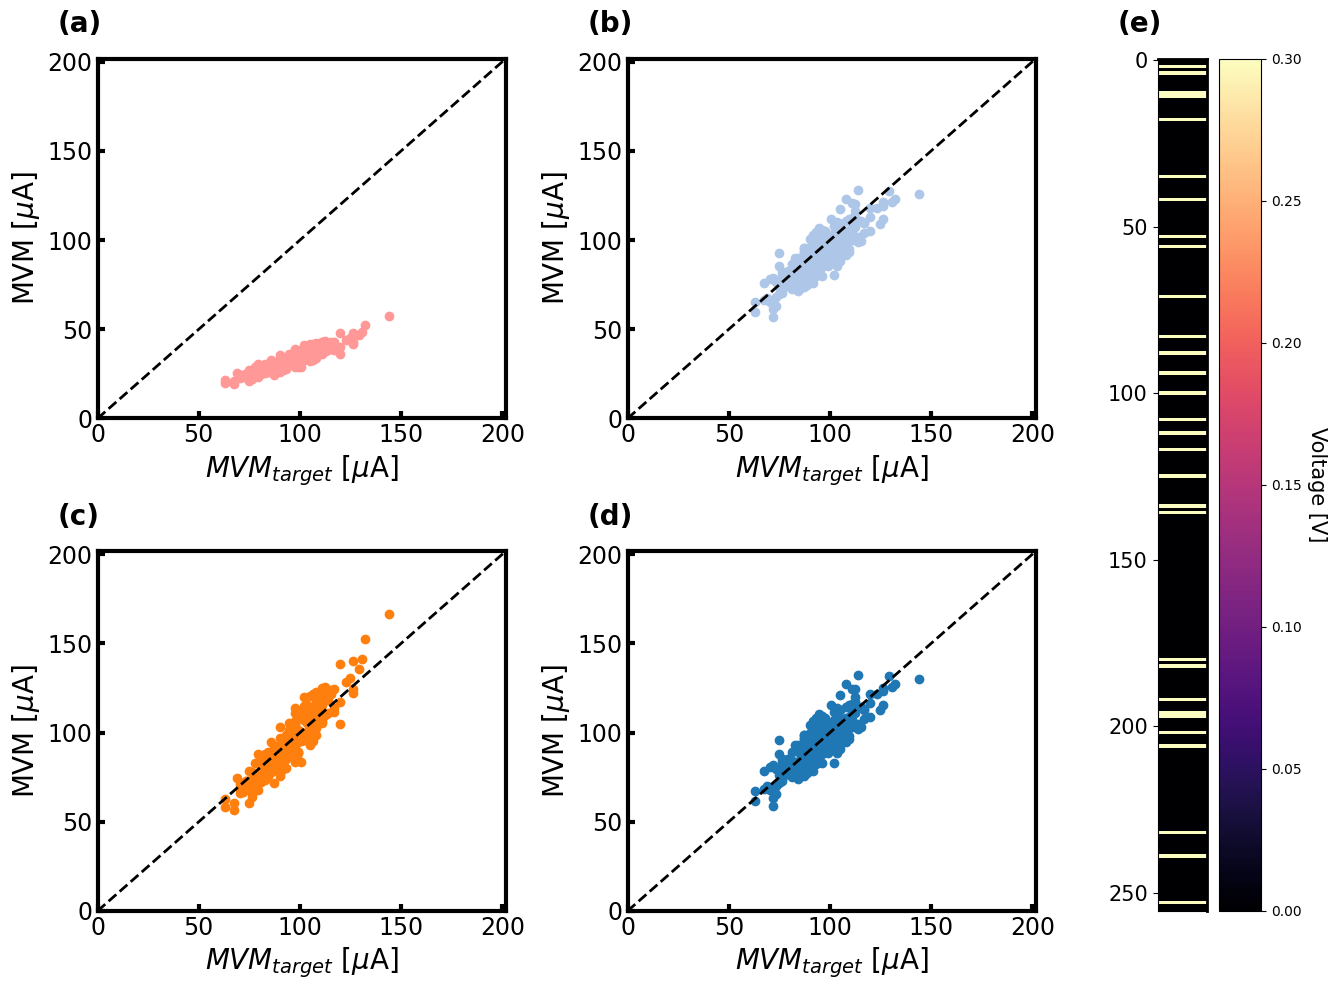

In [9]:


# now, benchmarking time: for each drifted tile, we compute the corrected currents for the 
# IBM correction and MSE correction
NO_CORRECTION_performance = np.zeros(len(M_values))
NO_CORRECTION_performance_std = np.zeros(len(M_values))
IBM_performance = np.zeros(len(M_values))
IBM_performance_std = np.zeros(len(M_values))
MSE_performance = np.zeros(len(M_values))
MSE_performance_std = np.zeros(len(M_values))
DIFF_performance = np.zeros(len(M_values))
DIFF_performance_std = np.zeros(len(M_values))
DIFF_IBM_performance = np.zeros(len(M_values))
DIFF_IBM_performance_std = np.zeros(len(M_values))

c_map = plt.get_cmap('tab20')
colors = [c_map(i) for i in range(8)]
colors = colors[:4] + [colors[-1]]
colors = colors[::-1]

for tile in range(len(M_values)):
    IBM_correction = np.sum(single_reference_currents[tile])/np.sum(reference_currents[tile])
    MSE_correction = np.dot(single_reference_currents[tile], single_reference_currents[tile])/np.dot(reference_currents[tile], single_reference_currents[tile])
    IBM_correction_differential = np.sum(differential_reference_currents[tile])/np.sum(reference_currents[tile])
    tile_NO_CORRECTION_performance = np.zeros(n_samples[tile])
    tile_IBM_performance = np.zeros(n_samples[tile])
    tile_MSE_performance = np.zeros(n_samples[tile])
    tile_DIFF_performance = np.zeros(n_samples[tile])
    tile_DIFF_IBM_performance = np.zeros(n_samples[tile])
    for sample in range(n_samples[tile]):
        # compute the ideal currents
        ideal_currents = np.zeros(M_values[tile])
        single_currents = np.zeros(M_values[tile])

        voltages = DAC_quantizer(inputs[tile][sample,:], BITS, V_dd, max_input)
        # voltages = np.array([V_dd]*N_values[tile])
        # print("Voltages: ", voltages)
        for c in range(M_values[tile]):
            ideal_currents[c] = np.dot(crossbars[tile][:,c], voltages)
            
        # compute the drifted currents
        for c in range(M_values[tile]):
            single_currents[c] = np.dot(single_crossbars[tile][:,c], voltages)
        
        # print("Ideal currents: ", ideal_currents)
        # print("Drifted currents: ", drifted_currents)
        # compute the correction factor for the current sample for the current tile
        # 0. No correction
        I_o = ideal_currents
        I_t = single_currents
        MAE_NO = compute_norm(I_o, I_t)
        tile_NO_CORRECTION_performance[sample] = MAE_NO

        # 1. IBM correction
        I_o = ideal_currents
        I_t = single_currents
        I_corrected = I_t/IBM_correction
        MAE_IBM = compute_norm(I_o, I_corrected)
        # print("MSE_IBM: ", MSE_IBM)
        tile_IBM_performance[sample] = MAE_IBM

        # 2. MSE correction
        I_o = ideal_currents
        I_t = single_currents
        I_corrected = I_t/MSE_correction
        MAE_MSE = compute_norm(I_o, I_corrected)
        tile_MSE_performance[sample] = MAE_MSE

        # 3. Differential
        I_o = ideal_currents
        I_corrected = np.zeros(M_values[tile])
        for c in range(M_values[tile]):
            I_corrected[c] = np.dot(differential_crossbars[tile][:,c], voltages)
        MAE_DIFF = compute_norm(I_o, I_corrected)
        tile_DIFF_performance[sample] = MAE_DIFF

        if tile == 3 and sample == 0:
            # Plot the currents
            fig, ax = plt.subplot_mosaic([["(a)", "(b)", "(e)"], ["(c)", "(d)", "(e)"]], figsize=(13,10), gridspec_kw={'width_ratios': [1, 1, 0.3]}, layout='constrained')

            for label, a in ax.items():
                # Use ScaledTranslation to put the label
                # - at the top left corner (axes fraction (0, 1)),
                # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
                # i.e. just outside the axes.
                a.text(
                    0.0, 1.0, label, transform=(
                        a.transAxes + ScaledTranslation(-20/50, +15/72, fig.dpi_scale_trans)),
                    fontsize=20, va='bottom', fontweight='bold')
            ax["(a)"].scatter( ideal_currents*1e6, single_currents*1e6, color=colors[0], label="Drifted currents")
            #ax["(a)"].set_title("single - no IBM comp.", fontsize=18)
            ax["(b)"].scatter( ideal_currents*1e6, I_corrected*1e6, color=colors[3], label="Drifted currents")
            #ax["(b)"].set_title("differential - no IBM comp.", fontsize=18)
            ax["(c)"].scatter( ideal_currents*1e6, single_currents*1e6/IBM_correction, color=colors[2], label="IBM corrected")
            #ax["(c)"].set_title("single - IBM comp.", fontsize=18)
            ax["(d)"].scatter( ideal_currents*1e6, I_corrected*1e6/IBM_correction_differential, color=colors[4], label="Differential IBM corrected")
            #ax["(d)"].set_title("differential - IBM comp.", fontsize=18)
            
            for label, a in ax.items():
                if label in ["(a)", "(b)", "(c)", "(d)"]:
                    a.set_xlabel(r"$MVM_{target}$ [$\mu$A]", fontsize=20)
                    a.set_ylabel(r"MVM [$\mu$A]", fontsize=20)
                    a.tick_params(axis='both', which='major', labelsize=17)
                    a.spines['top'].set_linewidth(3)
                    a.spines['right'].set_linewidth(3)
                    a.spines['left'].set_linewidth(3)
                    a.spines['bottom'].set_linewidth(3)
                    a.tick_params(axis='both', direction='in', width=3, length=5)
                    #increase tick size
                    a.axline((min(ideal_currents)*1e6,min(ideal_currents)*1e6),(max(ideal_currents)*1e6,max(ideal_currents)*1e6) , color='black', lw=2, linestyle='--')
                    a.set_xlim(0, max(ideal_currents)*1e6 + 0.4*max(ideal_currents)*1e6)
                    a.set_ylim(0, max(ideal_currents)*1e6 + 0.4*max(ideal_currents)*1e6)

            # fuse the last two axes objext together to create a single imshow plots
            # for the voltage vector used to create the simulated currents
            axbig = ax["(e)"]
            im = axbig.imshow(voltages.reshape(-1,1), cmap='magma', aspect='auto')
            # increase the size of the colorbar
            cbar = plt.colorbar(im, ax=axbig, fraction=0.5, pad=0.1)
            cbar.ax.set_ylabel("Voltage [V]", rotation=-90, va="bottom", fontsize=15)
            # axbig.set_title("wordlines \nvoltages", fontsize=18, y=1.05)
            axbig.tick_params(axis='y', which='major', labelsize=15)
            # remove ticks on the x-axis
            axbig.set_xticks([])
            axbig.spines['top'].set_linewidth(2)
            axbig.spines['right'].set_linewidth(2) 
            
            # Remove the colorbar before calling tight_layout
            cbar.remove()
            plt.tight_layout()
            
            # Recreate the colorbar after calling tight_layout
            cbar = plt.colorbar(im, ax=axbig, fraction=0.5, pad=0.1)
            cbar.ax.set_ylabel("Voltage [V]", rotation=-90, va="bottom", fontsize=15)
            
            plt.show()
            # save the plot to the drift directory
            fig.savefig(f"./d={CHOSEN_TYPE}/lv={n_levels}/currents_.png", dpi=300)

        # 4. Differential IBM
        I_o = ideal_currents
        I_corrected = np.zeros(M_values[tile])
        for c in range(M_values[tile]):
            I_corrected[c] = np.dot(differential_crossbars[tile][:,c], voltages)
        I_corrected = I_corrected/IBM_correction_differential
        MAE_DIFF_IBM = compute_norm(I_o, I_corrected)
        tile_DIFF_IBM_performance[sample] = MAE_DIFF_IBM

        

    NO_CORRECTION_performance[tile] = np.mean(tile_NO_CORRECTION_performance)
    NO_CORRECTION_performance_std[tile] = np.std(tile_NO_CORRECTION_performance)
    IBM_performance[tile] = np.mean(tile_IBM_performance)
    IBM_performance_std[tile] = np.std(tile_IBM_performance)
    MSE_performance[tile] = np.mean(tile_MSE_performance)
    MSE_performance_std[tile] = np.std(tile_MSE_performance)
    DIFF_performance[tile] = np.mean(tile_DIFF_performance)
    DIFF_performance_std[tile] = np.std(tile_DIFF_performance)
    DIFF_IBM_performance[tile] = np.mean(tile_DIFF_IBM_performance)
    DIFF_IBM_performance_std[tile] = np.std(tile_DIFF_IBM_performance)


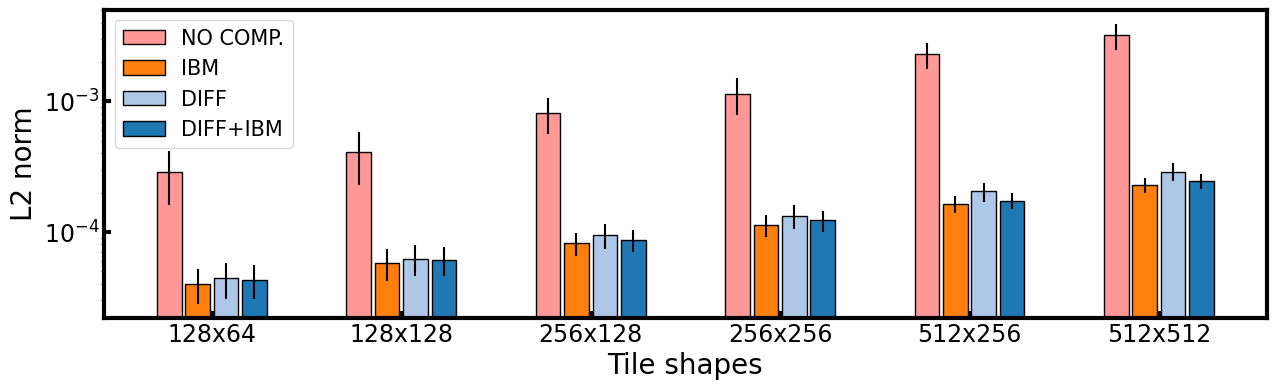

In [10]:
# Plot the performaces of the different corrections as batches of histograms
fig, ax = plt.subplots(1,1, figsize=(15,4))

# generate a group of histograms for each tile
# each group compares the performance of the 3 corrections
barWidth = 0.15
dimensions = np.arange(len(M_values))
r1 = [x - barWidth for x in dimensions]
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]
r5 = [x + barWidth for x in r4]


ax.bar(r1, NO_CORRECTION_performance, color=colors[0], width=barWidth -0.02, edgecolor='k', label='NO COMP.', yerr= NO_CORRECTION_performance_std* 2)
# ax.bar(r2, MSE_performance, color=colors[1], width=barWidth -0.02 , edgecolor='k', label='MSE')
ax.bar(r2, IBM_performance, color=colors[2], width=barWidth -0.02, edgecolor='k', label='IBM', yerr=IBM_performance_std* 2)
ax.bar(r3, DIFF_performance, color=colors[3], width=barWidth -0.02, edgecolor='k', label='DIFF', yerr=DIFF_performance_std* 2)
ax.bar(r4, DIFF_IBM_performance, color=colors[4], width=barWidth -0.02, edgecolor='k', label='DIFF+IBM', yerr=DIFF_IBM_performance_std* 2)
#set to log scale
ax.set_yscale('log')

ax.set_xlabel('Tile shapes', fontsize=20)
ax.set_ylabel('L2 norm', fontsize=20)
# for the xticks, use the shapes of the tiles
ax.set_xticks([r + barWidth/2 for r in range(len(M_values))])
ax.set_xticklabels(["{}x{}".format(N_values[i], M_values[i]) for i in range(len(M_values))], fontsize=17)
# make the frame thicker
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)

# make the ticks thicker and inwards
ax.tick_params(axis='both', direction='in', width=3, length=5)
# increase tick labels on y
ax.tick_params(axis='both', which='major', labelsize=17)

# set the grid on the background
# ax.grid(axis='y')
# grid on the background
ax.set_axisbelow(True)
ax.legend(fancybox=True, loc='upper left', fontsize=15)
# ax.set_title("MVM approximation quality on {}".format(CHOSEN_TYPE), fontsize=20)

# save the plot to the drift directory
fig.savefig(f"./d={CHOSEN_TYPE}/lv={n_levels}/performances.png", dpi=300)



In [6]:
# save the mean values of the performances in a csv file
import pandas as pd
df = pd.DataFrame({'NO_COMP': NO_CORRECTION_performance, 'IBM': IBM_performance, 'DIFF': DIFF_performance, 'DIFF_IBM': DIFF_IBM_performance})

df.to_csv(f"./d={CHOSEN_TYPE}/lv={n_levels}/performance.csv", index=False)

NameError: name 'NO_CORRECTION_performance' is not defined

Prog: [4.93129090e-04 7.04399246e-05 1.88873719e-04 1.77397525e-04]
30d,RT: [0.00296257 0.00020871 0.0004133  0.00022402]
1d,90°C: [0.00323286 0.00022837 0.00028966 0.00024369]
1d,150°C: [0.00435679 0.0004218  0.00040448 0.00025361]
1d,180°C: [0.00459639 0.00054588 0.00039062 0.00026837]


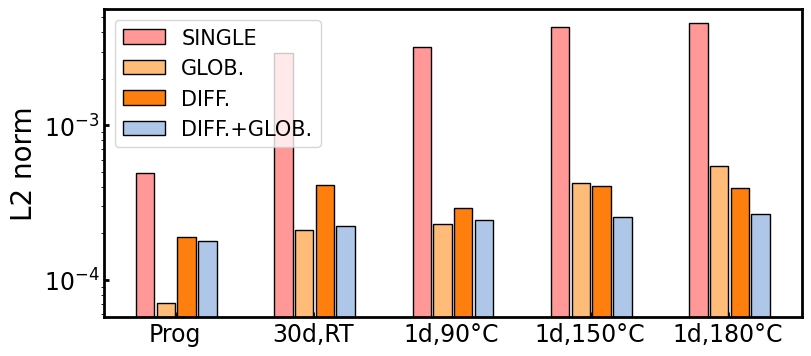

In [14]:
# Plot in a single graph the performances for each compensation, using as reference the 512x512 tile,
# at 9 levels of quantization. Define a vector of chosen noise types, and for each noise type, plot the performances
# of the different corrections
import pandas as pd
LEVEL = 9
N = 512
M = 512

c_map = plt.get_cmap('tab20')
colors = [c_map(i) for i in range(8)]
colors = colors[:4] + [colors[-1]]
colors = colors[::-1]


# define the noise types
CHOSEN_NOISE_TYPE = [types[0],types[2], types[4], types[6], types[7]]

performances = {noise: [] for noise in CHOSEN_NOISE_TYPE}

for noise in CHOSEN_NOISE_TYPE:
    # load the data saved in the csv file for the corresponding noise type
    # and level of quantization
    data = pd.read_csv(f"./d={noise}/lv={LEVEL}/performance.csv")
    # the data related to the 512x512 tile is in the last row
    # the column values are respectively NO_COMP,IBM,DIFF,DIFF_IBM
    performances[noise] = data.iloc[-1].values
    print(f"{noise}: {performances[noise]}")

# plot the performances
fig, ax = plt.subplots(1,1, figsize=(9,4))
barSpace = 1.5
r1 = np.arange(0, 0.9, 0.225) 

compensations = ["SINGLE","GLOB.","DIFF.","DIFF.+GLOB."]

for i, noise in enumerate(CHOSEN_NOISE_TYPE):
    for j in range(4):
        ax.bar(r1[j] + i*barSpace, performances[noise][j], color=colors[j], width=0.2, edgecolor='k', label='{}'.format(compensations[j]) if i == 0 else "")
    

ax.set_yscale('log')
# set minor locator for the y-axis log scale
ax.set_ylabel('L2 norm', fontsize=20)
ax.set_xticks([barSpace*r + 0.3225 for r in range(len(CHOSEN_NOISE_TYPE))])
ax.set_xticklabels(CHOSEN_NOISE_TYPE, fontsize=17)
# ax.grid(axis='y', which='minor', linestyle='--')
# ax.grid(axis='y', which='major')
ax.set_axisbelow(True)
ax.legend(fancybox=True, loc='upper left', fontsize=15)
# set the tick labels of the y-axis bigger
ax.tick_params(axis='y', which='major', labelsize=17)

#make the axis thicker
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# increase the size of the ticks
ax.tick_params(axis='both', direction='in', width=2)
